## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

# Práctica 19: Gradiente Descendiente en 2D como fundamento de entrenamiento de las redes de Deep Learning en R

• Definimos el error que comete una red neuronal como la diferencia entre el resultado esperado en una instancia de entrenamiento y el resultado obtenido.

• La idea principal es representar el error como una función continua de los pesos e intentar llevar la red hacia una configuración de valores de activación que nos permita encontrar el mínimo de esta función.

• Para determinar la magnitud y dirección del cambio que debemos introducir en el vector de pesos para reducir el error que está cometiendo, utilizaremos el concepto de «pendiente», que indica que la pendiente de un punto dado es el gradiente de la tangente a la curva de la función en el punto dado.

El gradiente es la derivada de una operación tensorial. Es la generalización del concepto de derivadas a funciones que toman tensores como entradas

En esta práctica implementaremos el gradiente descendiente en 2D para dar fundamento al entrenamiento de redes neuronales de Deep Learning.

### Paso 1: importar las librerías necesarias

### Paso 2: Definimos la función: f(x) = 2x^2 * cos(x) -5x

In [1]:
f <- function(x) {
  return(2 * x^2 * cos(x) - 5 * x)
}

###  Paso 3: Graficamos la función: f(x) = 2x^2 * cos(x) -5x

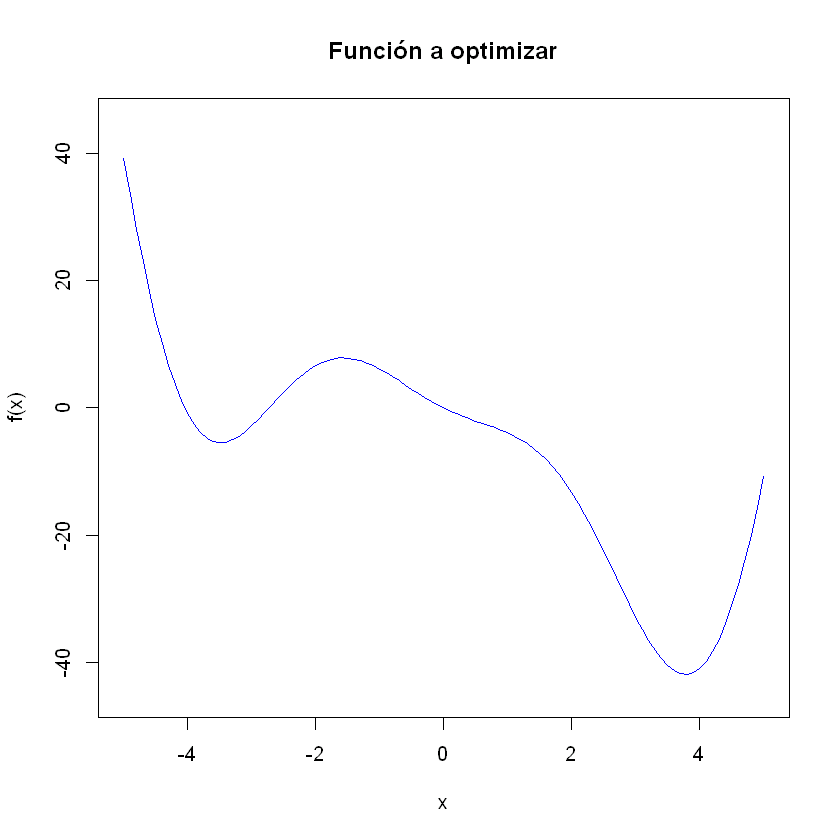

In [2]:
t1 <- seq(-5.0, 5.0, by = 0.1)

plot(t1, f(t1), type = "l", col = "blue", 
     xlim = c(-5, 5), ylim = c(-45, 45),
     xlab = "x", ylab = "f(x)", 
     main = "Función a optimizar")

# Paso 4:Implementamos el Algoritmo del Descenso del Gradiente

## Paso 4.1 Tome un Punto al azar X0.

X =  -1 
Y =  6.080605 


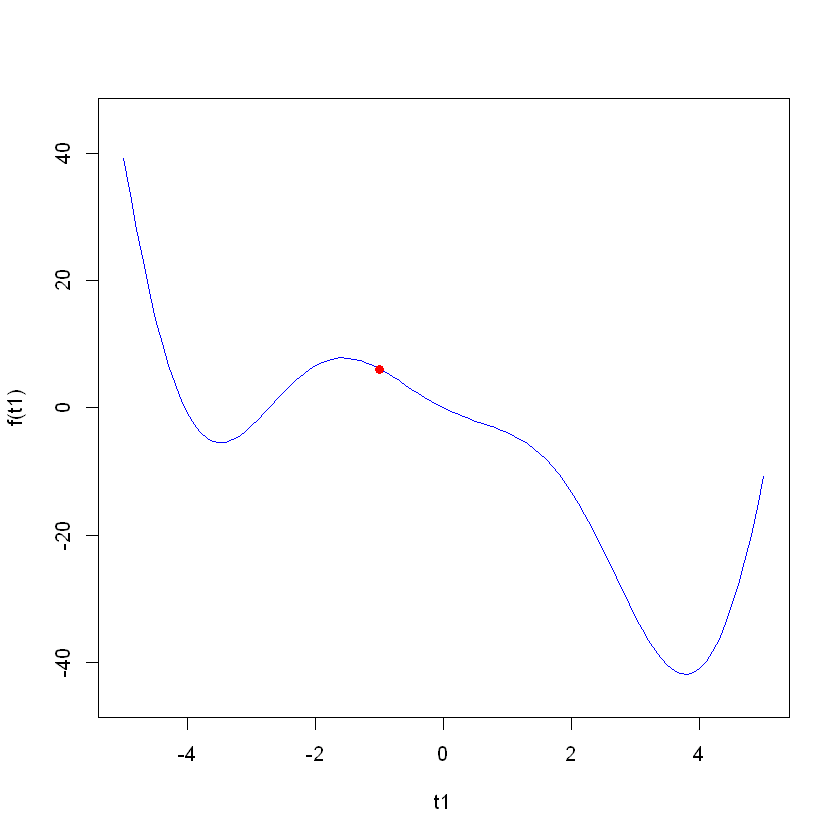

In [3]:
plot(t1, f(t1), type = "l", col = "blue", xlim = c(-5, 5), ylim = c(-45, 45))

x <- c(-1.0)
y <- c(f(x[1])) # Nota: En R el índice inicial es 1

# 'pch=19' es equivalente al círculo sólido, col="red" es el color
points(x, y, col = "red", pch = 19)

cat("X = ", x, "\n")
cat("Y = ", y, "\n")

Paso 4.2 Calcule el valor de la pendiente (derivada) f'(X0)

In [4]:
# La derivada de f (la pendiente)
df <- function(x) {
  return(4 * x * cos(x) - 2 * x^2 * sin(x) - 5)
}

pendiente <- df(x[1])
cat("Pendiente: ", pendiente, "\n")

Pendiente:  -5.478267 


## paso 4.3 Camine en dirección opuesta a la pendiente: x1=x0 - eta * f'(x0).
### Nota. Aquí eta es la tasa de aprendizaje que mencionamos previamente.

In [5]:
eta <- 0.05
#eta <- 0.7

# Usamos c() para concatenar (agregar) valores al vector, equivalente a .append()
x <- c(x, x[1] - eta * pendiente)
y <- c(y, f(x[1] - eta * pendiente))

cat("X = ", x, "\n")
cat("Y = ", y, "\n")

X =  -1 -0.7260866 
Y =  6.080605 4.418893 


## Graficamos el Segundo Punto.

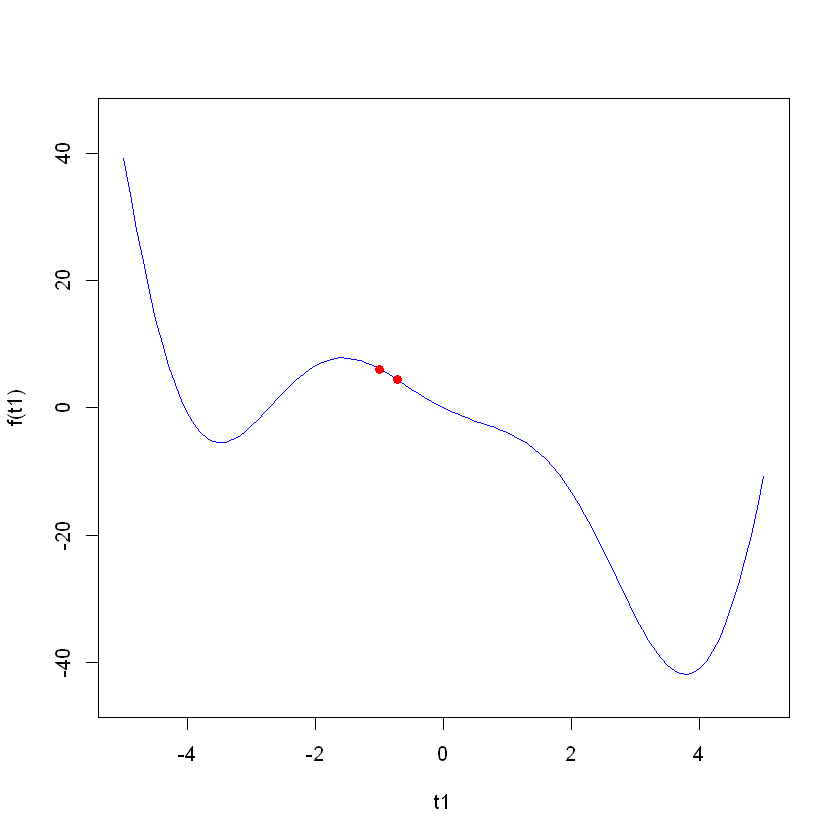

In [6]:
plot(t1, f(t1), type = "l", col = "blue", xlim = c(-5, 5), ylim = c(-45, 45))
points(x, y, col = "red", pch = 19)

## Graficamos un Tercer Punto.

X =  -1 -0.7260866 -0.4024997 
Y =  6.080605 4.418893 2.310617 
Pendiente x[1]:  -5.478267 
Pendiente x[2]:  -6.471738 
Pendiente x[3]:  -6.354413 


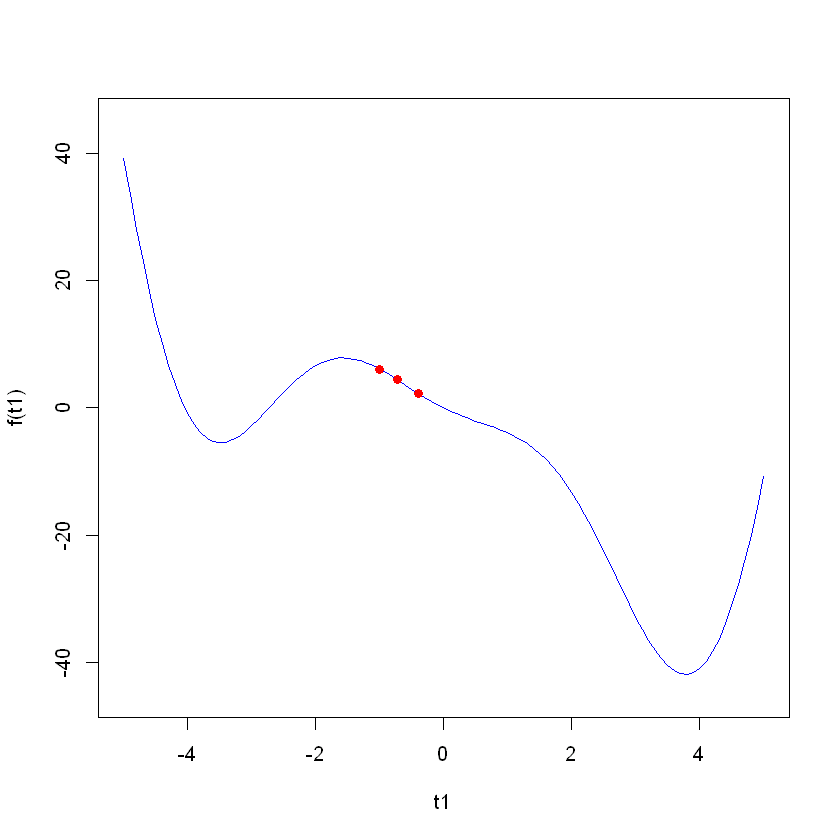

In [7]:
x <- c(x, x[2] - eta * df(x[2]))
y <- c(y, f(x[2] - eta * df(x[2])))

cat("X = ", x, "\n")
cat("Y = ", y, "\n")

# Calculamos e imprimimos las pendientes de los 3 puntos
cat("Pendiente x[1]: ", df(x[1]), "\n")
cat("Pendiente x[2]: ", df(x[2]), "\n")
cat("Pendiente x[3]: ", df(x[3]), "\n")

plot(t1, f(t1), type = "l", col = "blue", xlim = c(-5, 5), ylim = c(-45, 45))
points(x, y, col = "red", pch = 19)

## Graficamos 20 Puntos

             X           Y
1  -1.00000000   6.0806046
2  -0.72608664   4.4188934
3  -0.40249974   2.3106172
4  -0.08477906   0.4382187
5   0.18205499  -0.8450824
6   0.39684581  -1.6937341
7   0.57973188  -2.3363088
8   0.75114098  -2.9309266
9   0.92984359  -3.6152158
10  1.13794256  -4.6033762
11  1.41002624  -6.4136037
12  1.81113680 -10.6172857
13  2.46595230 -21.8197271
14  3.48109112 -40.2580997
15  3.98402398 -41.0511209
16  3.57991424 -41.1080699
17  3.93428386 -41.4012248
18  3.63414844 -41.4448964
19  3.90004434 -41.5826568
20  3.67008911 -41.6141484
21  3.87477934 -41.6859411


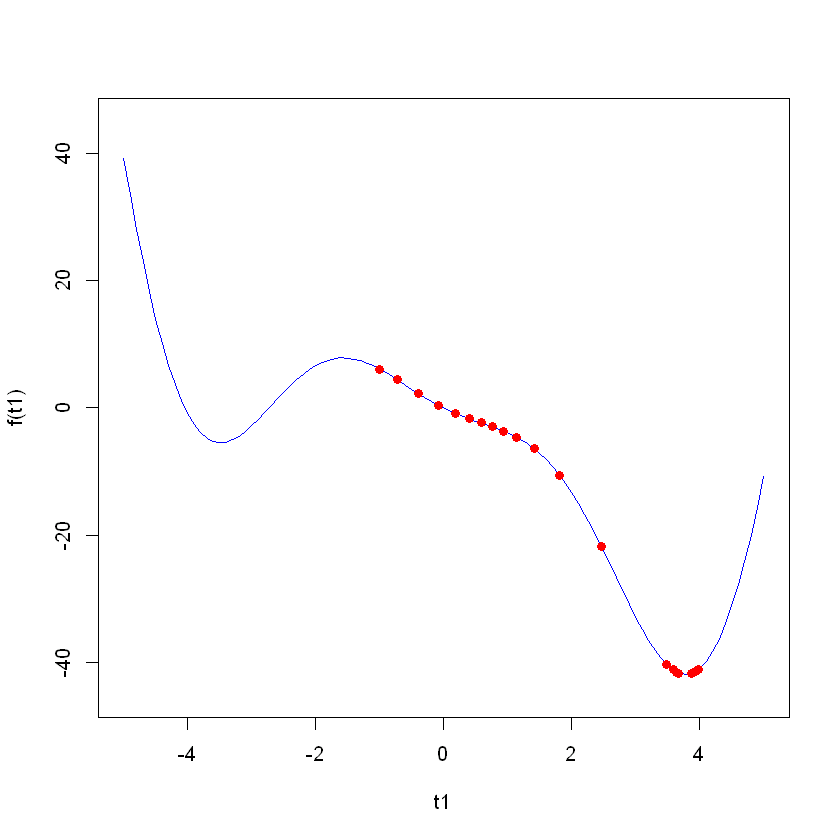

In [8]:
eta <- 0.05
#eta <- 0.7
x_vals <- c(-1.0)
y_vals <- c(f(x_vals[1]))

for (i in 1:20) {
  x_new <- x_vals[i] - eta * df(x_vals[i])
  y_new <- f(x_new)
  
  x_vals <- c(x_vals, x_new)
  y_vals <- c(y_vals, y_new)
}

# R tiene data.frames nativos, no se necesita importar pandas
dt <- data.frame(X = x_vals, Y = y_vals)
print(dt)

plot(t1, f(t1), type = "l", col = "blue", xlim = c(-5, 5), ylim = c(-45, 45))
points(x_vals, y_vals, col = "red", pch = 19)

## Conclusiones.

El gradiente es la derivada de una operación tensorial. Es la generalización del concepto de derivadas a funciones que toman tensores como entradas.

## Referencias

* Scikit-learn: Machine Learning in Python. (2026). Hierarchical clustering. URL: https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering
* Scikit-learn: Machine Learning in Python. (2026). Principal component analysis (PCA). URL: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
* Dr. Francisco Javier Luna Rosas. Material del curso Machine y Deep Learning.